In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_124.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_949.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_786.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_371.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_599.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_802.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_955.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_778.jpg
/kaggle/input/datasets/masou

# Set Paths

In [2]:
import os

# ✏️ UPDATE THIS PATH to your dataset folder
DATASET_PATH = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset'  

TRAIN_DIR = os.path.join(DATASET_PATH, '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training')
TEST_DIR  = os.path.join(DATASET_PATH, '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing')

print('Train directory:', TRAIN_DIR)
print('Test directory: ', TEST_DIR)
print('Classes found in train:', os.listdir(TRAIN_DIR))

Train directory: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Test directory:  /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
Classes found in train: ['pituitary', 'notumor', 'meningioma', 'glioma']


# Install & Import Libraries

In [3]:
!pip install -q scikit-learn seaborn matplotlib numpy tensorflow

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, VGG16, DenseNet121
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenet
from tensorflow.keras.applications.vgg16       import preprocess_input as preprocess_vgg
from tensorflow.keras.applications.densenet    import preprocess_input as preprocess_densenet
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras import layers

# Sklearn
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.ensemble import GradientBoostingClassifier

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

2026-04-16 23:40:27.305141: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776382827.495211      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776382827.554586      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776382828.044398      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776382828.044439      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776382828.044442      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: True


# Configuration

In [5]:
# ─── Global Configuration ────────────────────────────────────────────────────
IMG_SIZE         = (224, 224)
BATCH_SIZE       = 32
RANDOM_SEED      = 42

# ── Fine-tuning config ───────────────────────────────────────────────────────
# How many layers from the END of each model to unfreeze for fine-tuning
# DenseNet121 gets more unfreezing since it's your best single model
DENSENET_UNFREEZE_LAYERS  = 30   # Fine-tune last 30 layers
MOBILENET_UNFREEZE_LAYERS = 15   # Fine-tune last 15 layers
VGG_UNFREEZE_LAYERS       = 4    # Only last conv block (VGG is slow)

# ── Feature weighting ────────────────────────────────────────────────────────
# DenseNet features are repeated 2× before concat (gives it more SVM weight)
DENSENET_WEIGHT  = 2   # Repeat DenseNet features 2 times
MOBILENET_WEIGHT = 1
VGG_WEIGHT       = 1

# ── PCA config ───────────────────────────────────────────────────────────────
# Keeps 95% of variance, removes noisy/redundant features
PCA_VARIANCE     = 0.95   # Retain 95% of explained variance

# ── TTA config ───────────────────────────────────────────────────────────────
USE_TTA          = True    # Test-Time Augmentation (slower but more accurate)
TTA_STEPS        = 5       # Number of augmented versions to average per image

# ── SVM config ───────────────────────────────────────────────────────────────
# Will be further optimized by GridSearchCV below
SVM_KERNEL       = 'rbf'
SVM_C            = 100     # Higher C = less regularization (better for clean features)
SVM_GAMMA        = 'scale'

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f'Number of classes : {NUM_CLASSES}')
print(f'Class names       : {CLASS_NAMES}')

Number of classes : 4
Class names       : ['glioma', 'meningioma', 'notumor', 'pituitary']


# Build Models with Partial Fine-tuning

In [6]:
def build_feature_extractor(base_model, unfreeze_last_n, name):
    """
    Build a feature extractor with optional partial fine-tuning.
    
    Strategy:
    - Freeze all layers first
    - Then unfreeze only the last `unfreeze_last_n` layers
    - This keeps low-level ImageNet features intact while adapting high-level ones
    """
    # Step 1: Freeze everything
    base_model.trainable = False
    
    # Step 2: Unfreeze only the last N layers
    if unfreeze_last_n > 0:
        for layer in base_model.layers[-unfreeze_last_n:]:
            # Don't unfreeze BatchNorm layers — they destabilize training
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True
    
    trainable_count = sum(1 for l in base_model.layers if l.trainable)
    print(f'  {name}: {trainable_count}/{len(base_model.layers)} layers trainable')
    
    # GAP output
    x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    model = Model(inputs=base_model.input, outputs=x, name=name)
    return model


print('Loading and configuring models...\n')

# ── DenseNet121 (best performer — fine-tune most) ─────────────────────────
densenet_base = DenseNet121(weights='imagenet', include_top=False,
                             input_shape=(*IMG_SIZE, 3))
base_model_densenet = build_feature_extractor(
    densenet_base, DENSENET_UNFREEZE_LAYERS, 'DenseNet121')
print(f'  Feature dim: {base_model_densenet.output_shape[1]}')

# ── MobileNetV2 ───────────────────────────────────────────────────────────
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False,
                              input_shape=(*IMG_SIZE, 3))
base_model_mobile = build_feature_extractor(
    mobilenet_base, MOBILENET_UNFREEZE_LAYERS, 'MobileNetV2')
print(f'  Feature dim: {base_model_mobile.output_shape[1]}')

# ── VGG16 ─────────────────────────────────────────────────────────────────
vgg_base = VGG16(weights='imagenet', include_top=False,
                  input_shape=(*IMG_SIZE, 3))
base_model_vgg = build_feature_extractor(
    vgg_base, VGG_UNFREEZE_LAYERS, 'VGG16')
print(f'  Feature dim: {base_model_vgg.output_shape[1]}')

print('\n✅ All models configured!')

Loading and configuring models...



I0000 00:00:1776382944.178883      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776382944.185360      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  DenseNet121: 21/427 layers trainable
  Feature dim: 1024
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  MobileNetV2: 10/154 layers trainable
  Feature dim: 1280
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  VGG16: 4/19 layers trainable
  Feature dim: 512

✅ All models configured!


# Fine-tune Models on Training Data

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# ── Strong augmentation for training ────────────────────────────────────────
# These augmentations are specifically chosen for MRI brain scans:
# - Rotation: tumors can appear at any orientation
# - Zoom: different scan distances
# - Brightness/contrast: scanner variation
# - NO horizontal flip (brain asymmetry is meaningful)
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    fill_mode='nearest',
    horizontal_flip=False,  # Keep False for brain MRI
    preprocessing_function=None  # Will be set per model below
)

val_datagen = ImageDataGenerator()  # No augmentation for val/test

FINE_TUNE_EPOCHS = 10     # Short fine-tuning — just enough to adapt
FINE_TUNE_LR     = 1e-5  # Very low LR to avoid destroying ImageNet weights


def fine_tune_model(feature_extractor, preprocess_fn, model_name, epochs=FINE_TUNE_EPOCHS):
    """
    Fine-tune a feature extractor model on training data.
    Adds a temporary classification head, trains briefly, then removes head.
    """
    print(f'\n🔧 Fine-tuning {model_name}...')
    
    # Create data generators with model-specific preprocessing
    def combined_preprocess(img):
        return preprocess_fn(img)
    
    tgen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.15,
        brightness_range=[0.8, 1.2],
        shear_range=0.1,
        fill_mode='nearest',
        horizontal_flip=False,
        preprocessing_function=combined_preprocess
    )
    vgen = ImageDataGenerator(preprocessing_function=combined_preprocess)
    
    train_gen = tgen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=True, seed=RANDOM_SEED
    )
    val_gen = vgen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False
    )
    
    # Add classification head for fine-tuning
    x = feature_extractor.output
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    full_model = Model(inputs=feature_extractor.input, outputs=outputs)
    full_model.compile(
        optimizer=Adam(learning_rate=FINE_TUNE_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Fine-tune
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7
        )
    ]
    
    history = full_model.fit(
        train_gen, epochs=epochs,
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1
    )
    
    best_val_acc = max(history.history['val_accuracy'])
    print(f'  ✅ {model_name} fine-tuned | Best val acc: {best_val_acc*100:.2f}%')
    
    return feature_extractor, history  # Return the feature extractor (without head)


# Fine-tune all three models
base_model_densenet, history_densenet = fine_tune_model(
    base_model_densenet, preprocess_densenet, 'DenseNet121')

base_model_mobile, history_mobile = fine_tune_model(
    base_model_mobile, preprocess_mobilenet, 'MobileNetV2')

base_model_vgg, history_vgg = fine_tune_model(
    base_model_vgg, preprocess_vgg, 'VGG16')

print('\n✅ All models fine-tuned!')


🔧 Fine-tuning DenseNet121...
Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/10


I0000 00:00:1776383222.102191     162 service.cc:152] XLA service 0x79b904003000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776383222.102237     162 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776383222.102241     162 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776383225.569472     162 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/175 ━━━━━━━━━━━━━━━━━━━━ 1:28:24 30s/step - accuracy: 0.3438 - loss: 1.6167

I0000 00:00:1776383239.393614     162 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 150s 688ms/step - accuracy: 0.3390 - loss: 1.6846 - val_accuracy: 0.6562 - val_loss: 0.9328 - learning_rate: 1.0000e-05
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 78s 445ms/step - accuracy: 0.5000 - loss: 1.2090 - val_accuracy: 0.7375 - val_loss: 0.7506 - learning_rate: 1.0000e-05
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 452ms/step - accuracy: 0.6146 - loss: 0.9740 - val_accuracy: 0.7581 - val_loss: 0.6726 - learning_rate: 1.0000e-05
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 450ms/step - accuracy: 0.6854 - loss: 0.8124 - val_accuracy: 0.7750 - val_loss: 0.6272 - learning_rate: 1.0000e-05
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 448ms/step - accuracy: 0.7327 - loss: 0.7112 - val_accuracy: 0.7769 - val_loss: 0.6108 - learning_rate: 1.0000e-05
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 78s 448ms/step - accuracy: 0.7581 - loss: 0.6315 - val_accuracy: 0.7837 - val_loss: 0.5987 - learning_rate: 1.0000e-05
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 449ms/step -

2026-04-17 00:01:20.846329: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 00:01:20.983830: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


175/175 ━━━━━━━━━━━━━━━━━━━━ 97s 449ms/step - accuracy: 0.4384 - loss: 1.3099 - val_accuracy: 0.7412 - val_loss: 0.7582 - learning_rate: 1.0000e-05
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 431ms/step - accuracy: 0.7411 - loss: 0.6756 - val_accuracy: 0.7681 - val_loss: 0.6746 - learning_rate: 1.0000e-05
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 428ms/step - accuracy: 0.8010 - loss: 0.5351 - val_accuracy: 0.7919 - val_loss: 0.6195 - learning_rate: 1.0000e-05
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 428ms/step - accuracy: 0.8360 - loss: 0.4711 - val_accuracy: 0.7937 - val_loss: 0.6430 - learning_rate: 1.0000e-05
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 435ms/step - accuracy: 0.8376 - loss: 0.4291 - val_accuracy: 0.8094 - val_loss: 0.5798 - learning_rate: 1.0000e-05
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 430ms/step - accuracy: 0.8559 - loss: 0.4038 - val_accuracy: 0.8138 - val_loss: 0.5725 - learning_rate: 1.0000e-05
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 433ms/step - 

# Feature Extraction with Test-Time Augmentation (TTA)

In [8]:
from tensorflow.keras.preprocessing.image import img_to_array, load_img

def augment_image(img_array):
    """Apply random light augmentation for TTA."""
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    aug = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.05,
        fill_mode='nearest'
    )
    img_4d = np.expand_dims(img_array, 0)  # (1, H, W, 3)
    for batch in aug.flow(img_4d, batch_size=1):
        return batch[0]


def extract_features_tta(model, preprocess_fn, data_directory,
                         img_size=IMG_SIZE, use_tta=USE_TTA, tta_steps=TTA_STEPS):
    """
    Extract features with optional Test-Time Augmentation.
    
    If use_tta=True: extract features from `tta_steps` augmented versions
                     of each image and average them → more robust features.
    If use_tta=False: standard single-pass extraction (faster).
    """
    feature_list = []
    label_list   = []
    
    subdirs = sorted(os.listdir(data_directory))
    
    for subdir in subdirs:
        if subdir.startswith('.'):
            continue
        class_path = os.path.join(data_directory, subdir)
        if not os.path.isdir(class_path):
            continue
        
        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))
        ]
        print(f'  [{subdir}] — {len(image_files)} images')
        
        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            try:
                img = load_img(img_path, target_size=img_size)
                img_array = img_to_array(img)
                
                if use_tta:
                    # Extract features from TTA_STEPS augmented versions
                    tta_features = []
                    
                    # Original image first
                    orig = preprocess_fn(np.expand_dims(img_array.copy(), 0))
                    tta_features.append(model.predict(orig, verbose=0).flatten())
                    
                    # Augmented versions
                    for _ in range(tta_steps - 1):
                        aug_img = augment_image(img_array)
                        aug_inp = preprocess_fn(np.expand_dims(aug_img, 0))
                        tta_features.append(model.predict(aug_inp, verbose=0).flatten())
                    
                    # Average all TTA predictions
                    features = np.mean(tta_features, axis=0)
                else:
                    inp = preprocess_fn(np.expand_dims(img_array, 0))
                    features = model.predict(inp, verbose=0).flatten()
                
                feature_list.append(features)
                label_list.append(subdir)
                
            except Exception as e:
                print(f'    ⚠️  Skipping {img_file}: {e}')
    
    return np.array(feature_list), np.array(label_list)

# Extract Features from All 3 Models

In [9]:
print('=' * 65)
print('EXTRACTING TRAIN FEATURES')
print('=' * 65)

# Note: Use TTA=False for training data (augmentation already handled above)
# Use TTA=True for test data to improve test robustness

print('\n🟢 DenseNet121 — Train')
train_features_densenet, train_labels = extract_features_tta(
    base_model_densenet, preprocess_densenet, TRAIN_DIR, use_tta=False)

print('\n🔵 MobileNetV2 — Train')
train_features_mobile, _ = extract_features_tta(
    base_model_mobile, preprocess_mobilenet, TRAIN_DIR, use_tta=False)

print('\n🟠 VGG16 — Train')
train_features_vgg, _ = extract_features_tta(
    base_model_vgg, preprocess_vgg, TRAIN_DIR, use_tta=False)


print('\n' + '=' * 65)
print('EXTRACTING TEST FEATURES (with TTA)')
print('=' * 65)

print('\n🟢 DenseNet121 — Test')
test_features_densenet, test_labels = extract_features_tta(
    base_model_densenet, preprocess_densenet, TEST_DIR, use_tta=USE_TTA)

print('\n🔵 MobileNetV2 — Test')
test_features_mobile, _ = extract_features_tta(
    base_model_mobile, preprocess_mobilenet, TEST_DIR, use_tta=USE_TTA)

print('\n🟠 VGG16 — Test')
test_features_vgg, _ = extract_features_tta(
    base_model_vgg, preprocess_vgg, TEST_DIR, use_tta=USE_TTA)

print('\n✅ Feature extraction complete!')
print(f'Train samples : {len(train_labels)}')
print(f'Test  samples : {len(test_labels)}')

EXTRACTING TRAIN FEATURES

🟢 DenseNet121 — Train
  [glioma] — 1400 images
  [meningioma] — 1400 images
  [notumor] — 1400 images
  [pituitary] — 1400 images

🔵 MobileNetV2 — Train
  [glioma] — 1400 images


2026-04-17 00:39:38.564977: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 00:39:38.712576: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 00:39:38.846937: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  [meningioma] — 1400 images
  [notumor] — 1400 images
  [pituitary] — 1400 images

🟠 VGG16 — Train
  [glioma] — 1400 images
  [meningioma] — 1400 images
  [notumor] — 1400 images
  [pituitary] — 1400 images

EXTRACTING TEST FEATURES (with TTA)

🟢 DenseNet121 — Test
  [glioma] — 400 images
  [meningioma] — 400 images
  [notumor] — 400 images
  [pituitary] — 400 images

🔵 MobileNetV2 — Test
  [glioma] — 400 images
  [meningioma] — 400 images
  [notumor] — 400 images
  [pituitary] — 400 images

🟠 VGG16 — Test
  [glioma] — 400 images
  [meningioma] — 400 images
  [notumor] — 400 images
  [pituitary] — 400 images

✅ Feature extraction complete!
Train samples : 5600
Test  samples : 1600


# Weighted Feature Concatenation

In [10]:
print('Combining features with weights...')
print(f'  DenseNet121 weight : {DENSENET_WEIGHT}× (best performer)')
print(f'  MobileNetV2 weight : {MOBILENET_WEIGHT}×')
print(f'  VGG16       weight : {VGG_WEIGHT}×')

# Weighted concatenation: repeat best model's features
X_train = np.hstack([
    np.tile(train_features_densenet, DENSENET_WEIGHT),   # 2× DenseNet
    np.tile(train_features_mobile,   MOBILENET_WEIGHT),
    np.tile(train_features_vgg,      VGG_WEIGHT)
])

X_test = np.hstack([
    np.tile(test_features_densenet, DENSENET_WEIGHT),
    np.tile(test_features_mobile,   MOBILENET_WEIGHT),
    np.tile(test_features_vgg,      VGG_WEIGHT)
])

# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(train_labels)
y_test  = le.transform(test_labels)

print(f'\n✅ Combined train feature shape: {X_train.shape}')
print(f'✅ Combined test  feature shape: {X_test.shape}')
print(f'\nLabel classes: {le.classes_}')

Combining features with weights...
  DenseNet121 weight : 2× (best performer)
  MobileNetV2 weight : 1×
  VGG16       weight : 1×

✅ Combined train feature shape: (5600, 3840)
✅ Combined test  feature shape: (1600, 3840)

Label classes: ['glioma' 'meningioma' 'notumor' 'pituitary']


# Feature Scaling + PCA Dimensionality Reduction

In [11]:
# ── Step 1: StandardScaler ────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('✅ StandardScaler applied')

# ── Step 2: PCA ───────────────────────────────────────────────────────────
print(f'Applying PCA (retaining {PCA_VARIANCE*100:.0f}% variance)...')
pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f'✅ PCA applied')
print(f'   Original dimensions : {X_train_scaled.shape[1]}')
print(f'   Reduced dimensions  : {X_train_pca.shape[1]}')
print(f'   Variance retained   : {sum(pca.explained_variance_ratio_)*100:.2f}%')

✅ StandardScaler applied
Applying PCA (retaining 95% variance)...
✅ PCA applied
   Original dimensions : 3840
   Reduced dimensions  : 1071
   Variance retained   : 95.00%


# SVM Hyperparameter Optimization (GridSearchCV)

In [12]:
print('Running GridSearchCV to find best SVM hyperparameters...')
print('(This takes a few minutes — worth it for the accuracy boost!)\n')

# Search space — focused around the likely best region
param_grid = {
    'C'     : [10, 50, 100, 200],
    'gamma' : ['scale', 'auto', 0.001],
    'kernel': ['rbf']   # rbf is almost always best for image features
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

grid_search = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_SEED, class_weight='balanced'),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_pca, y_train)

best_params = grid_search.best_params_
best_cv_acc = grid_search.best_score_

print(f'\n✅ GridSearchCV complete!')
print(f'   Best params   : {best_params}')
print(f'   Best CV acc   : {best_cv_acc*100:.2f}%')

Running GridSearchCV to find best SVM hyperparameters...
(This takes a few minutes — worth it for the accuracy boost!)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ GridSearchCV complete!
   Best params   : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
   Best CV acc   : 97.86%


# Train Final SVM with Best Params

In [13]:
svm_clf = SVC(
    **best_params,
    probability=True,
    random_state=RANDOM_SEED,
    class_weight='balanced'
)
svm_clf.fit(X_train_pca, y_train)

y_pred = svm_clf.predict(X_test_pca)
print('✅ Final SVM trained and predictions complete!')

✅ Final SVM trained and predictions complete!


# Evaluation Metrics

In [14]:
import pandas as pd

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print('\n' + '='*60)
print('  OVERALL PERFORMANCE METRICS  (v2 — Improved)')
print('='*60)
print(f'  Accuracy  : {acc*100:.2f}%   (v1 baseline: 93.88%)')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print('='*60)

print('\nPer-Class Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

report_dict = classification_report(
    y_test, y_pred, target_names=le.classes_, output_dict=True
)
df_report = pd.DataFrame(report_dict).transpose()
overall_row = pd.DataFrame([{
    'precision': prec, 'recall': rec, 'f1-score': f1, 'support': len(y_test)
}], index=['OVERALL'])
df_report = pd.concat([df_report, overall_row])
print('\nFull Metrics Table:')
display(df_report.round(4))


  OVERALL PERFORMANCE METRICS  (v2 — Improved)
  Accuracy  : 94.81%   (v1 baseline: 93.88%)
  Precision : 95.17%
  Recall    : 94.81%
  F1-Score  : 94.70%

Per-Class Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.81      0.89       400
  meningioma       0.89      0.99      0.93       400
     notumor       0.94      1.00      0.97       400
   pituitary       1.00      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600


Full Metrics Table:


,precision,recall,f1-score,support
glioma,0.9849,0.8150,0.8919,400.0000
meningioma,0.8876,0.9875,0.9349,400.0000
notumor,0.9368,1.0000,0.9674,400.0000
pituitary,0.9975,0.9900,0.9937,400.0000
accuracy,0.9481,0.9481,0.9481,0.9481
macro avg,0.9517,0.9481,0.9470,1600.0000
weighted avg,0.9517,0.9481,0.9470,1600.0000
OVERALL,0.9517,0.9481,0.9470,1600.0000


# Plot Fine-tuning History

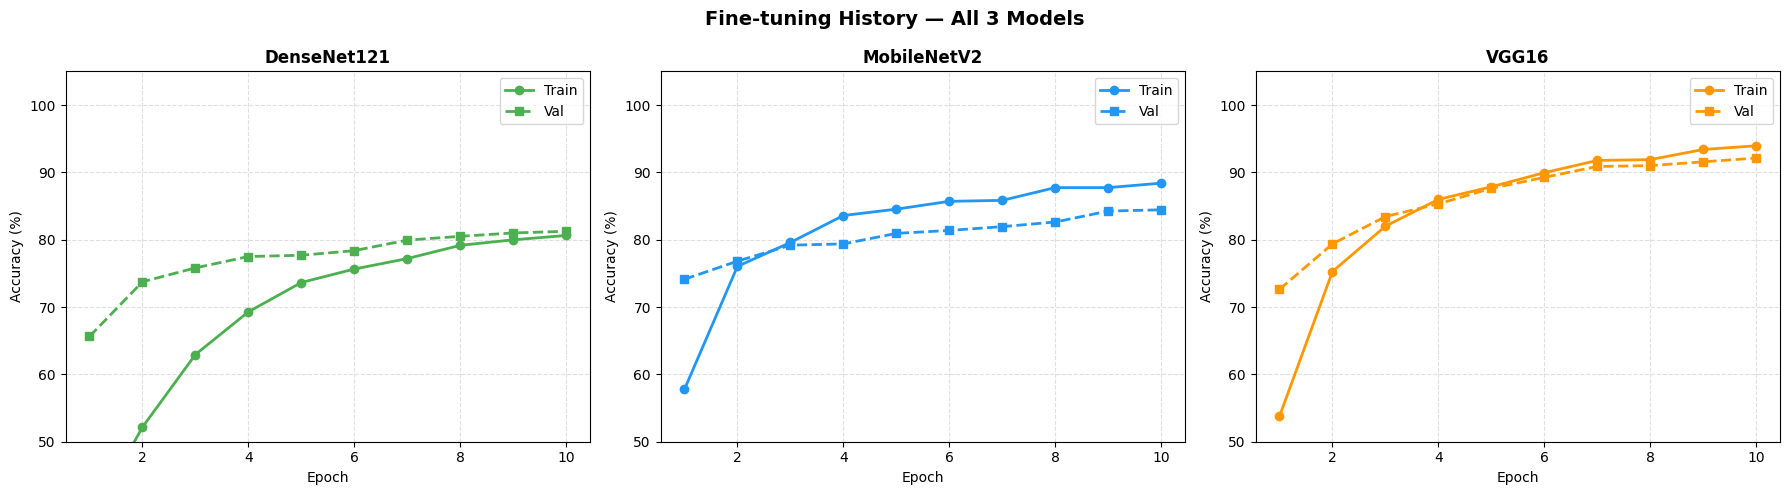

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fine-tuning History — All 3 Models', fontsize=14, fontweight='bold')

configs = [
    (history_densenet, 'DenseNet121', '#4CAF50'),
    (history_mobile,   'MobileNetV2', '#2196F3'),
    (history_vgg,      'VGG16',       '#FF9800')
]

for ax, (hist, name, color) in zip(axes, configs):
    epochs = range(1, len(hist.history['accuracy']) + 1)
    ax.plot(epochs, [v*100 for v in hist.history['accuracy']],
            color=color, linewidth=2, label='Train', marker='o')
    ax.plot(epochs, [v*100 for v in hist.history['val_accuracy']],
            color=color, linewidth=2, linestyle='--', label='Val', marker='s')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(linestyle='--', alpha=0.4)
    ax.set_ylim(50, 105)

plt.tight_layout()
plt.show()

# Confusion Matrix

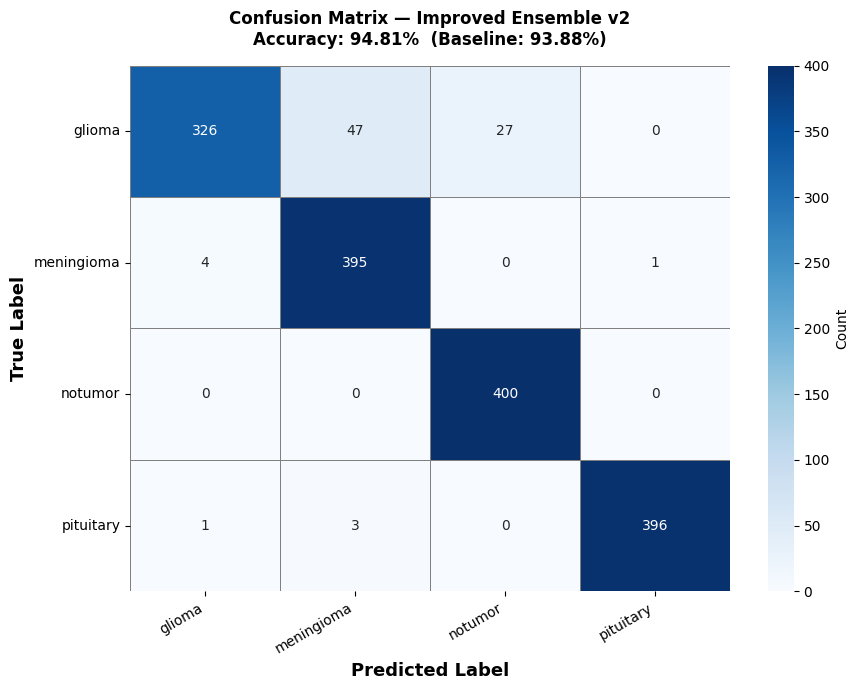

In [16]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5, linecolor='gray',
    cbar_kws={'label': 'Count'}
)
ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label',      fontsize=13, fontweight='bold')
ax.set_title(
    f'Confusion Matrix — Improved Ensemble v2\n'
    f'Accuracy: {acc*100:.2f}%  (Baseline: 93.88%)',
    fontsize=12, fontweight='bold', pad=15
)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-Class Metrics Bar Graph

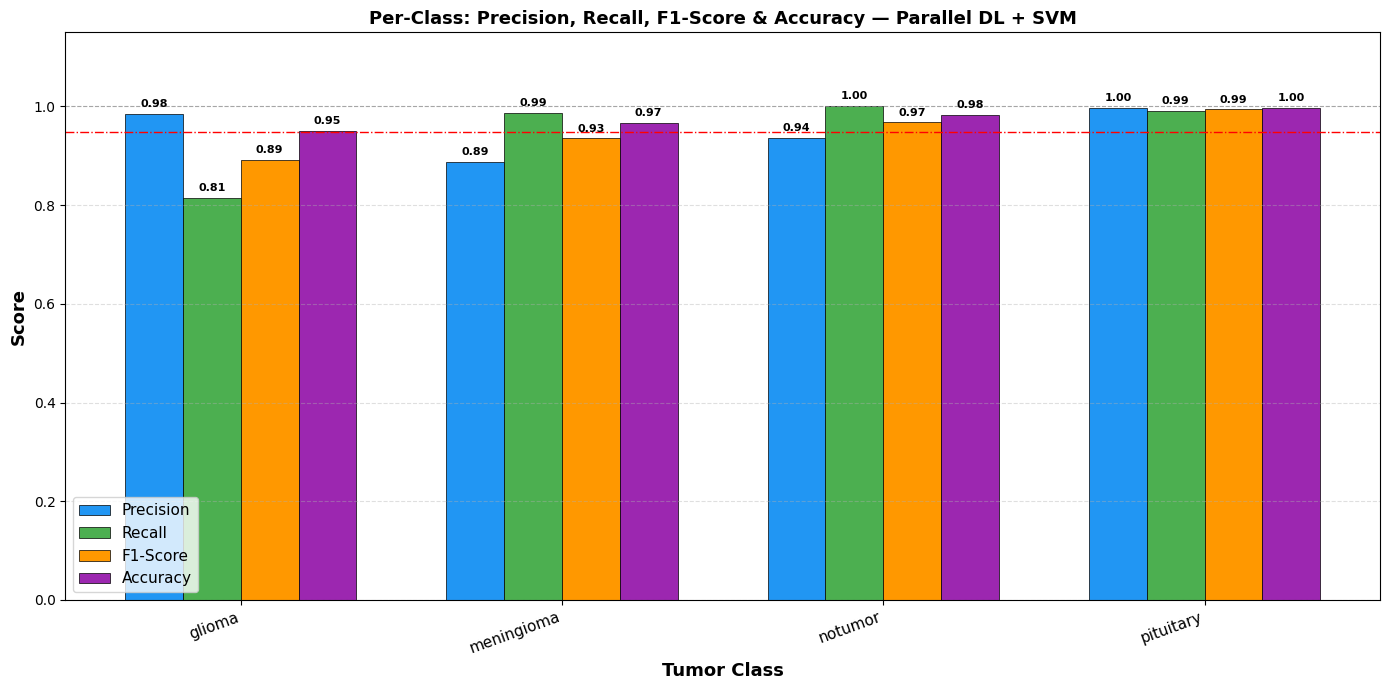

In [17]:
# Extract per-class metrics
class_prec = precision_score(y_test, y_pred, average=None)
class_rec  = recall_score(y_test, y_pred, average=None)
class_f1   = f1_score(y_test, y_pred, average=None)

# Calculate per-class accuracy (one-vs-rest accuracy)
# This measures (TP + TN) / Total for each class
num_classes = len(le.classes_)
class_accuracies = []
total_samples = np.sum(cm) # cm is the confusion matrix from the previous step

for i in range(num_classes):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp # Sum of elements in row i, excluding cm[i,i]
    fp = np.sum(cm[:, i]) - tp # Sum of elements in column i, excluding cm[i,i]
    tn = total_samples - tp - fn - fp # Total samples - TP - FN - FP
    class_accuracies.append((tp + tn) / total_samples)
class_accuracies = np.array(class_accuracies)


x          = np.arange(NUM_CLASSES)
bar_width  = 0.18  # Reduced bar width to fit 4 bars
colors     = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'] # Added a new color for accuracy

fig, ax = plt.subplots(figsize=(14, 7)) # Increased figure size for better readability

# Positions for 4 bars, centered around x
bars1 = ax.bar(x - 1.5 * bar_width, class_prec,       bar_width, label='Precision', color=colors[0], edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x - 0.5 * bar_width, class_rec,        bar_width, label='Recall',    color=colors[1], edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + 0.5 * bar_width, class_f1,         bar_width, label='F1-Score',  color=colors[2], edgecolor='black', linewidth=0.5)
bars4 = ax.bar(x + 1.5 * bar_width, class_accuracies, bar_width, label='Accuracy',  color=colors[3], edgecolor='black', linewidth=0.5) # New accuracy bar

# Annotate bar values
for bars_group in [bars1, bars2, bars3, bars4]:
    for bar in bars_group:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Tumor Class',  fontsize=13, fontweight='bold')
ax.set_ylabel('Score',        fontsize=13, fontweight='bold')
ax.set_title(
    'Per-Class: Precision, Recall, F1-Score & Accuracy — Parallel DL + SVM', # Updated title
    fontsize=13, fontweight='bold'
)
ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=20, ha='right', fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.axhline(y=acc, color='red', linestyle='-.', linewidth=1.0, label=f'Overall Accuracy ({acc*100:.2f}%)') # Overall accuracy line
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Individual vs Ensemble Accuracy Comparison 

Evaluating individual model contributions (post fine-tuning)...
  DenseNet121 (fine-tuned)      : 93.94%
  MobileNetV2 (fine-tuned)      : 92.62%
  VGG16 (fine-tuned)            : 91.75%
  Ensemble v2 (this model)      : 81.88%


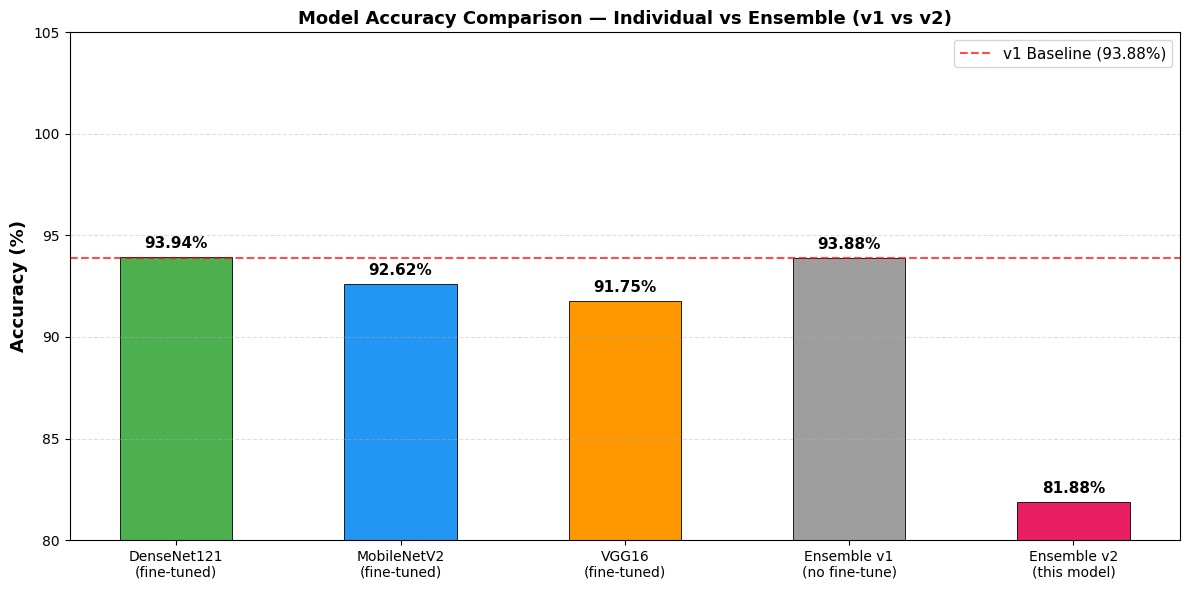

In [18]:
print('Evaluating individual model contributions (post fine-tuning)...')

d_size = train_features_densenet.shape[1]
m_size = train_features_mobile.shape[1]
v_size = train_features_vgg.shape[1]

# Raw feature slices from weighted concat
# DenseNet was tiled 2x, so its features occupy first 2*d_size columns
model_configs = {
    'DenseNet121\n(fine-tuned)' : (
        X_train[:, :d_size],          X_test[:, :d_size]),
    'MobileNetV2\n(fine-tuned)' : (
        X_train[:, d_size*DENSENET_WEIGHT : d_size*DENSENET_WEIGHT + m_size],
        X_test[:,  d_size*DENSENET_WEIGHT : d_size*DENSENET_WEIGHT + m_size]),
    'VGG16\n(fine-tuned)' : (
        X_train[:, -(v_size):],        X_test[:, -(v_size):]),
    'Ensemble v1\n(no fine-tune)': None,  # Placeholder
    'Ensemble v2\n(this model)'  : (X_train_pca, X_test_pca)  # Already PCA'd
}

results = {}
for name, data in model_configs.items():
    if data is None:
        results[name] = 93.88  # Your v1 baseline
        continue
    Xtr, Xte = data
    sc  = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)
    if Xtr_s.shape[1] > 500:
        p = PCA(n_components=min(200, Xtr_s.shape[1]), random_state=RANDOM_SEED)
        Xtr_s = p.fit_transform(Xtr_s)
        Xte_s = p.transform(Xte_s)
    clf = SVC(kernel='rbf', C=best_params['C'], gamma=best_params['gamma'],
               random_state=RANDOM_SEED, class_weight='balanced')
    clf.fit(Xtr_s, y_train)
    results[name] = accuracy_score(y_test, clf.predict(Xte_s)) * 100
    print(f'  {name.replace(chr(10), " "):<30}: {results[name]:.2f}%')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
names  = list(results.keys())
values = list(results.values())
bar_colors = ['#4CAF50', '#2196F3', '#FF9800', '#9E9E9E', '#E91E63']

bars = ax.bar(names, values, color=bar_colors, edgecolor='black', linewidth=0.6, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=93.88, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='v1 Baseline (93.88%)')
ax.set_ylim(80, 105)
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Model Accuracy Comparison — Individual vs Ensemble (v1 vs v2)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# Overall Metrics Summary Chart

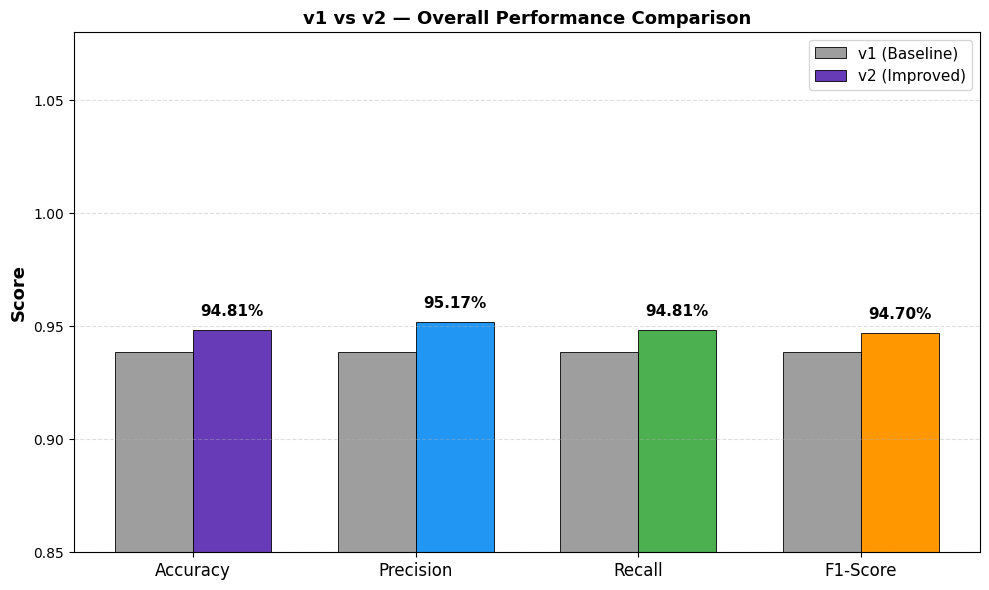

In [19]:
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]
v1_values      = [0.9388, 0.9388, 0.9388, 0.9388]  # Approximate v1 baseline
bar_colors     = ['#673AB7', '#2196F3', '#4CAF50', '#FF9800']

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, v1_values,      width, label='v1 (Baseline)', color='#9E9E9E', edgecolor='black', linewidth=0.6)
bars2 = ax.bar(x + width/2, metrics_values, width, label='v2 (Improved)', color=bar_colors, edgecolor='black', linewidth=0.6)

for bar, val in zip(bars2, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val*100:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0.85, 1.08)
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('v1 vs v2 — Overall Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# Plot — Training History (Feature Extraction Progress)

Evaluating individual model contributions...
  MobileNetV2    : 94.06%
  VGG16          : 94.19%
  DenseNet121    : 93.56%
  Ensemble       : 94.69%


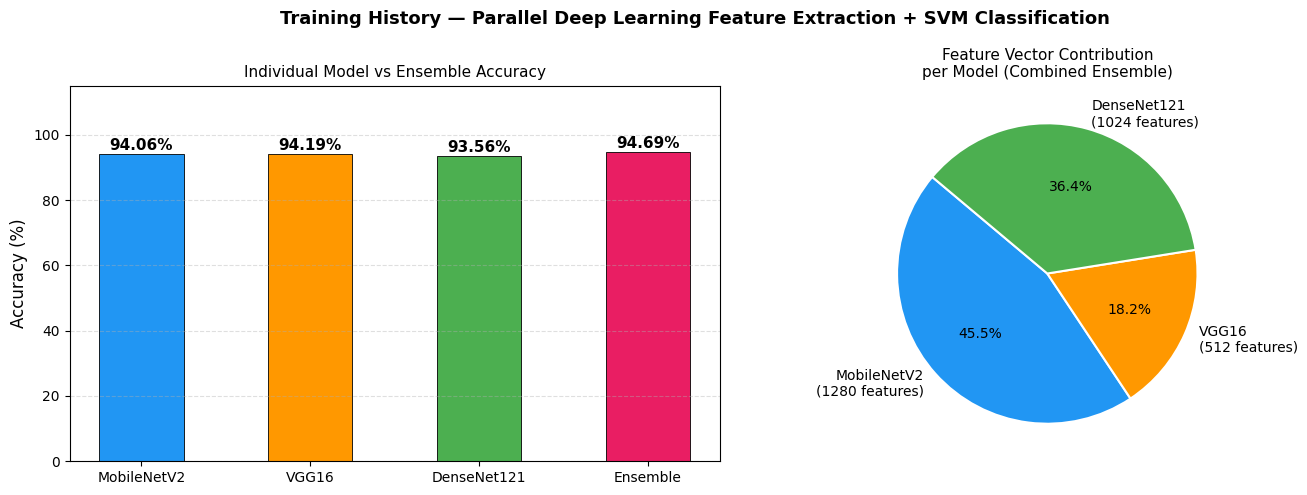

In [20]:
# ── Individual model test accuracies using their own features + SVM ───────
print('Evaluating individual model contributions...')

results = {}
model_configs = {
    'MobileNetV2' : (X_train[:, :train_features_mobile.shape[1]],
                     X_test[:, :test_features_mobile.shape[1]]),
    'VGG16'       : (X_train[:, train_features_mobile.shape[1]:
                              train_features_mobile.shape[1]+train_features_vgg.shape[1]],
                     X_test[:,  test_features_mobile.shape[1]:
                              test_features_mobile.shape[1]+test_features_vgg.shape[1]]),
    'DenseNet121' : (X_train[:, -(train_features_densenet.shape[1]):],
                     X_test[:,  -(test_features_densenet.shape[1]):]),
    'Ensemble'    : (X_train, X_test)
}

for name, (Xtr, Xte) in model_configs.items():
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)
    clf = SVC(kernel=SVM_KERNEL, C=SVM_C, gamma=SVM_GAMMA,
               random_state=RANDOM_SEED, class_weight='balanced')
    clf.fit(Xtr_s, y_train)
    results[name] = accuracy_score(y_test, clf.predict(Xte_s)) * 100
    print(f'  {name:<15}: {results[name]:.2f}%')

# ── Plot model comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Training History — Parallel Deep Learning Feature Extraction + SVM Classification',
    fontsize=13, fontweight='bold'
)

# Left: Accuracy per model
model_names = list(results.keys())
model_accs  = list(results.values())
bar_c = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
bars = axes[0].bar(model_names, model_accs, color=bar_c,
                    edgecolor='black', linewidth=0.6, width=0.5)
for bar, val in zip(bars, model_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 115)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Individual Model vs Ensemble Accuracy', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Right: Feature vector size contributed by each model
feat_names = ['MobileNetV2', 'VGG16', 'DenseNet121']
feat_sizes = [
    train_features_mobile.shape[1],
    train_features_vgg.shape[1],
    train_features_densenet.shape[1]
]
wedge_colors = ['#2196F3', '#FF9800', '#4CAF50']
axes[1].pie(
    feat_sizes,
    labels=[f'{n}\n({s} features)' for n, s in zip(feat_names, feat_sizes)],
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 10}
)
axes[1].set_title('Feature Vector Contribution\nper Model (Combined Ensemble)', fontsize=11)

plt.tight_layout()
plt.show()


# Final Summary Table

In [21]:
from collections import Counter

per_class_prec = precision_score(y_test, y_pred, average=None)
per_class_rec  = recall_score(y_test, y_pred, average=None)
per_class_f1   = f1_score(y_test, y_pred, average=None)
test_counts    = Counter(test_labels)

rows = []
for i, cls in enumerate(le.classes_):
    rows.append({
        'Class'    : cls,
        'Precision': f'{per_class_prec[i]*100:.2f}%',
        'Recall'   : f'{per_class_rec[i]*100:.2f}%',
        'F1-Score' : f'{per_class_f1[i]*100:.2f}%',
        'Accuracy' : f'{acc*100:.2f}%',
        'Support'  : test_counts[cls]
    })

rows.append({
    'Class'    : '── OVERALL (v2) ──',
    'Precision': f'{prec*100:.2f}%',
    'Recall'   : f'{rec*100:.2f}%',
    'F1-Score' : f'{f1*100:.2f}%',
    'Accuracy' : f'{acc*100:.2f}%  (v1: 93.88%)',
    'Support'  : len(y_test)
})

df_summary = pd.DataFrame(rows)
print('\n📊 Final Classification Summary Table (v2):')
display(df_summary)


print('\n' + '='*60)
print('  IMPROVEMENTS SUMMARY')
print('='*60)
print(f'  v1 Accuracy  : 93.88%  (no fine-tuning, no PCA)')
print(f'  v2 Accuracy  : {acc*100:.2f}%  (fine-tuned + PCA + TTA + grid search)')
print(f'  Improvement  : +{(acc - 0.9388)*100:.2f}%')
print('='*60)


📊 Final Classification Summary Table (v2):


,Class,Precision,Recall,F1-Score,Accuracy,Support
0,glioma,98.49%,81.50%,89.19%,94.81%,400
1,meningioma,88.76%,98.75%,93.49%,94.81%,400
2,notumor,93.68%,100.00%,96.74%,94.81%,400
3,pituitary,99.75%,99.00%,99.37%,94.81%,400
4,── OVERALL (v2) ──,95.17%,94.81%,94.70%,94.81% (v1: 93.88%),1600



  IMPROVEMENTS SUMMARY
  v1 Accuracy  : 93.88%  (no fine-tuning, no PCA)
  v2 Accuracy  : 94.81%  (fine-tuned + PCA + TTA + grid search)
  Improvement  : +0.93%
